In [37]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
from matplotlib.colors import LinearSegmentedColormap
import os
import scipy.stats as stats

In [2]:
sam_mg = SAM()
sam_mg.load_data('Active_SAM_joined/SAM_Allen_Institute_allhypo_01272026.h5ad')

In [3]:
with open('parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [4]:
plt_df_saturn = pd.DataFrame(index = [i for i in sam_mg.adata.obs['subclass_id_label'].unique() if parent_dict[parent_dict[i]] == 'hypo'],
                      columns = ['mg','mo','cj','ac','xt','dr'])
plt_df_samap = pd.DataFrame(index = [i for i in sam_mg.adata.obs['subclass_id_label'].unique() if parent_dict[parent_dict[i]] == 'hypo'],
                      columns = ['mg','mo','cj','ac','xt','dr'])
plt_df_NT = pd.DataFrame(index = [i for i in sam_mg.adata.obs['subclass_id_label'].unique() if parent_dict[parent_dict[i]] == 'hypo'],
                      columns = ['mg','mo','cj','ac','xt','dr'])

In [79]:
fn = 'Active_SAM_joined/SAM_DR_ncbi_03142025.h5ad'

In [80]:
sam = SAM()
sam.load_data(fn)

In [81]:
org = 'dr'

In [82]:
lsaturn_m = pd.read_csv('SATURN_mapping/DR_30_seeds.csv', index_col = 'barcode')

In [83]:
ind = pd.read_csv('Active_SAMap_Joined/DR_MG_mapping_cleaned_03122025_0.csv')['Unnamed: 0']
lsamap_m = pd.DataFrame(index = list(ind))
for i in range(30):
    df = pd.read_csv('Active_SAMap_Joined/DR_MG_mapping_cleaned_03122025_' + str(i) + '.csv', index_col = 'Unnamed: 0')
    lsamap_m = pd.concat([lsamap_m, df], axis = 1)

In [57]:
lsaturn_m

,seed_0,seed_1,seed_2,seed_3,seed_4,seed_5,seed_6,seed_7,seed_8,seed_9,...,seed_20,seed_21,seed_22,seed_23,seed_24,seed_25,seed_26,seed_27,seed_28,seed_29
barcode,,,,,,,,,,,,,,,,,,,,,
AAACCTGAGAGTTGGC 97,328 OEC NN,319 Astro-TE NN,320 Astro-OLF NN,328 OEC NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,328 OEC NN,320 Astro-OLF NN,320 Astro-OLF NN,...,325 CHOR NN,316 Bergmann NN,320 Astro-OLF NN,320 Astro-OLF NN,328 OEC NN,328 OEC NN,319 Astro-TE NN,328 OEC NN,251 NTS Dbh Glut,316 Bergmann NN
AAACCTGCAAGCGTAG 97,060 OT D3 Folh1 Gaba,149 PVT-PT Ntrk1 Glut,285 MY Lhx1 Gly-Gaba,201 PAG-RN Nkx2-2 Otx1 Gaba,262 Pineal Crx Glut,282 POR Spp1 Gly-Gaba,228 PSV Pvalb Lhx2 Glut,321 Astroependymal NN,322 Tanycyte NN,307 RO-RPA Pkd2l1 Gaba,...,320 Astro-OLF NN,032 L5 NP CTX Glut,329 ABC NN,322 Tanycyte NN,321 Astroependymal NN,331 Peri NN,045 OB-STR-CTX Inh IMN,321 Astroependymal NN,261 HB Calcb Chol,123 DMH Nkx2-4 Glut
AAACCTGCAGTAGAGC 97,113 MEA-COA-BMA Ccdc42 Glut,121 MEA-BST Otp Zic2 Glut,013 COAp Grxcr2 Glut,013 COAp Grxcr2 Glut,113 MEA-COA-BMA Ccdc42 Glut,120 MEA Otp Foxp2 Glut,120 MEA Otp Foxp2 Glut,013 COAp Grxcr2 Glut,013 COAp Grxcr2 Glut,013 COAp Grxcr2 Glut,...,113 MEA-COA-BMA Ccdc42 Glut,013 COAp Grxcr2 Glut,177 SCig-an-PPT Foxb1 Glut,113 MEA-COA-BMA Ccdc42 Glut,002 IT EP-CLA Glut,013 COAp Grxcr2 Glut,001 CLA-EPd-CTX Car3 Glut,113 MEA-COA-BMA Ccdc42 Glut,013 COAp Grxcr2 Glut,018 L2 IT PPP-APr Glut
AAACCTGCATCACCCT 97,321 Astroependymal NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,319 Astro-TE NN,321 Astroependymal NN,045 OB-STR-CTX Inh IMN,...,319 Astro-TE NN,337 DC NN,322 Tanycyte NN,321 Astroependymal NN,317 Astro-CB NN,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,319 Astro-TE NN,319 Astro-TE NN,337 DC NN
AAACCTGGTAAGAGAG 97,333 Endo NN,332 SMC NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,...,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTTGAACTC 96,129 VMH Nr5a1 Glut,128 VMH Fezf1 Glut,018 L2 IT PPP-APr Glut,129 VMH Nr5a1 Glut,128 VMH Fezf1 Glut,129 VMH Nr5a1 Glut,128 VMH Fezf1 Glut,129 VMH Nr5a1 Glut,128 VMH Fezf1 Glut,129 VMH Nr5a1 Glut,...,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut
TTTGTCATCAGCTGGC 96,055 STR Lhx8 Gaba,207 SCs Dmbx1 Gaba,053 Sst Gaba,093 RT-ZI Gnb3 Gaba,209 SCs Pax7 Nfia Gaba,053 Sst Gaba,052 Pvalb Gaba,048 RHP-COA Ndnf Gaba,310 CBX Golgi Gly-Gaba,212 SCs Lef1 Gli3 Gaba,...,209 SCs Pax7 Nfia Gaba,053 Sst Gaba,075 MEA-BST Lhx6 Nr2e1 Gaba,052 Pvalb Gaba,310 CBX Golgi Gly-Gaba,056 Sst Chodl Gaba,059 GPe-SI Sox6 Cyp26b1 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,079 CEA-BST Six3 Cyp26b1 Gaba,211 SC Tnnt1 Gli3 Gaba
TTTGTCATCATCATTC 96,050 Lamp5 Lhx6 Gaba,042 OB-out Frmd7 Gaba,067 LSX Sall3 Pax6 Gaba,054 STR Prox1 Lhx6 Gaba,044 OB Dopa-Gaba,052 Pvalb Gaba,043 OB-mi Frmd7 Gaba,035 OB Eomes Ms4a15 Glut,051 Pvalb chandelier Gaba,094 SCH Six6 Cdc14a Gaba,...,058 PAL-STR Gaba-Chol,055 STR Lhx8 Gaba,050 Lamp5 Lhx6 Gaba,067 LSX Sall3 Pax6 Gaba,042 OB-out Frmd7 Gaba,044 OB Dopa-Gaba,086 MPO-ADP Lhx8 Gaba,213 SCsg Gabrr2 Gaba,213 SCsg Gabrr2 Gaba,042 OB-out Frmd7 Gaba


In [58]:
lsamap_m

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
AAACCTGAGAGTTGGC 97,320 Astro-OLF NN,319 Astro-TE NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,...,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN
AAACCTGCAAGCGTAG 97,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,...,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN
AAACCTGCAGTAGAGC 97,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,...,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,073 MEA-BST Sox6 Gaba
AAACCTGCATCACCCT 97,038 DG-PIR Ex IMN,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,038 DG-PIR Ex IMN,045 OB-STR-CTX Inh IMN,038 DG-PIR Ex IMN,038 DG-PIR Ex IMN,038 DG-PIR Ex IMN,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,...,038 DG-PIR Ex IMN,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,038 DG-PIR Ex IMN,045 OB-STR-CTX Inh IMN
AAACCTGGTAAGAGAG 97,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,...,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN,333 Endo NN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTTGAACTC 96,146 LH Pou4f1 Sox1 Glut,135 STN-PSTN Pitx2 Glut,168 SPA-SPFm-SPFp-POL-PIL-PoT Sp9 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,138 PH Pitx2 Glut,135 STN-PSTN Pitx2 Glut,146 LH Pou4f1 Sox1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,135 STN-PSTN Pitx2 Glut,168 SPA-SPFm-SPFp-POL-PIL-PoT Sp9 Glut,...,135 STN-PSTN Pitx2 Glut,146 LH Pou4f1 Sox1 Glut,135 STN-PSTN Pitx2 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,135 STN-PSTN Pitx2 Glut,146 LH Pou4f1 Sox1 Glut,138 PH Pitx2 Glut,146 LH Pou4f1 Sox1 Glut,146 LH Pou4f1 Sox1 Glut,167 PRC-PAG Tcf7l2 Irx2 Glut
TTTGTCATCAGCTGGC 96,206 SCm-PAG Cdh23 Gaba,206 SCm-PAG Cdh23 Gaba,198 IC Six3 En2 Gaba,212 SCs Lef1 Gli3 Gaba,206 SCm-PAG Cdh23 Gaba,206 SCm-PAG Cdh23 Gaba,212 SCs Lef1 Gli3 Gaba,206 SCm-PAG Cdh23 Gaba,206 SCm-PAG Cdh23 Gaba,198 IC Six3 En2 Gaba,...,205 SC-PAG Lef1 Emx2 Gaba,212 SCs Lef1 Gli3 Gaba,212 SCs Lef1 Gli3 Gaba,212 SCs Lef1 Gli3 Gaba,206 SCm-PAG Cdh23 Gaba,205 SC-PAG Lef1 Emx2 Gaba,206 SCm-PAG Cdh23 Gaba,206 SCm-PAG Cdh23 Gaba,206 SCm-PAG Cdh23 Gaba,205 SC-PAG Lef1 Emx2 Gaba
TTTGTCATCATCATTC 96,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,...,057 NDB-SI-MA-STRv Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba
TTTGTCATCCGATATG 96,091 ARH-PVi Six6 Dopa-Gaba,091 ARH-PVi Six6 Dopa-Gaba,091 ARH-PVi Six6 Dopa-Gaba,091 ARH-PVi Six6 Dopa-Gaba,091 ARH-PVi Six6 Dopa-Gaba,091 ARH-PVi Six6 Dopa-Gaba,091 ARH-PVi Six6 Dopa-Gaba,091 ARH-PVi Six6 Dopa-Gaba,091 AR

In [17]:
meta_folder = 'Active_SAMap_Joined/MO_metadata/'

In [18]:
mn = os.listdir('Active_SAMap_Joined/MO_metadata/')

In [19]:
pd.read_csv(meta_folder + mn[3])

,Unnamed: 0,orig.ident,nCount_RNA,nFeature_RNA,n_counts,n_genes,key,eq_subclass_nounlabeled,leiden_removal,SCT_snn_res.5,leiden_clusters,subclass_id_label_mapping,subclass_id_label_lc
0,AAACCCATCTCAAAGC,MO,11772.0,3844,11772.0,3844,Run12_sample1,mo_9,35,15,86,Unlabeled,86
1,AAACGAACAGCACGAA,MO,4877.0,2561,4877.0,2561,Run12_sample1,mo_5,39,105,240,Unlabeled,240
2,AAACGAAGTCGGCACT,MO,5221.0,2859,5221.0,2859,Run12_sample1,108 ARH-PVp Tbx3 Gaba,35,14,16,108 ARH-PVp Tbx3 Gaba,16
3,AAACGAATCCACCCTA,MO,7922.0,3360,7922.0,3360,Run12_sample1,mo_2,78,87,527,Unlabeled,527
4,AAACGAATCCCAGCGA,MO,7020.0,3204,7020.0,3204,Run12_sample1,128 VMH Fezf1 Glut,2,16,333,128 VMH Fezf1 Glut,333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75325,TTTGTTGGTACTAACC,MO,5496.0,2569,5496.0,2569,Run12_sample12,057 NDB-SI-MA-STRv Lhx8 Gaba,8,26,156,057 NDB-SI-MA-STRv Lhx8 Gaba,156
75326,TTTGTTGGTCACAATC-1,MO,2974.0,1804,2974.0,1804,Run12_sample12,089 PVR Six3 Sox3 Gaba,11,52,119,089 PVR Six3 Sox3 Gaba,119
75327,TTTGTTGTCCAACCAA,MO,5601.0,2608,5601.0,2608,Run12_sample12,mo_9,5,56,265,Unlabeled,265
75328,TTTGTTGTCCCTGTTG,MO,6209.0,2759,6209.0,2759,Run12_sample12,mo_3,1,33,522,Unlabeled,522


In [20]:
test = pd.read_csv(meta_folder + mn[0])['subclass_id_label_mapping']

In [21]:
barcodes = pd.read_csv(meta_folder + mn[0])['Unnamed: 0']

In [22]:
raw_lc = pd.read_csv(meta_folder + mn[0])['subclass_id_label_lc']

In [23]:
df_lc = pd.DataFrame(data = list(raw_lc), index = list(barcodes), columns = ['raw_lc'])

In [24]:
mode_df = pd.DataFrame(index = [a for a in range(len(test))], columns = [b for b in range(len(mn))])
for j in range(len(mn)):
    print(mn[j])
    dat = list(pd.read_csv(meta_folder + mn[j])['subclass_id_label_lc'])
    mode_df.loc[:,j] = dat

MO_metadata_soupxplus5_cleaned_03122025_subclass_250_22.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_8.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_17.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_11.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_18.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_19.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_14.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_15.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_7.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_25.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_28.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_29.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_16.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_13.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_24.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_21.csv
MO_metadata_soupxplus5_cleaned_03122025_su

In [25]:
fin = []
for item in mode_df.columns:
    fin.append(mode_df.loc[10000,item])

In [26]:
stats.mode(fin)

ModeResult(mode=array([62]), count=array([30]))

In [27]:
lsamap_mv = pd.DataFrame(index = [a for a in barcodes], columns = [b for b in range(len(mn))])
for j in range(len(mn)):
    dat = list(pd.read_csv(meta_folder + mn[j])['subclass_id_label_mapping'])
    lsamap_mv.loc[:,j] = dat

In [28]:
lsamap_m = lsamap_mv

In [22]:
lsamap_m

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
AAACCCATCTCAAAGC,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,...,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled
AAACGAACAGCACGAA,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,...,Unlabeled,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,Unlabeled,Unlabeled,Unlabeled,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,Unlabeled,Unlabeled
AAACGAAGTCGGCACT,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,...,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba
AAACGAATCCACCCTA,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,...,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled
AAACGAATCCCAGCGA,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,...,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTACTAACC,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,...,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba
TTTGTTGGTCACAATC-1,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,...,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba
TTTGTTGTCCAACCAA,107 DMH Hmx2 Gaba,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,107 DMH Hmx2 Gaba,...,107 DMH Hmx2 Gaba,Unlabeled,Unlabeled,Unlabeled,Unlabeled,107 DMH Hmx2 Gaba,Unlabeled,Unlabeled,Unlabeled,Unlabeled
TTTGTTGTCCCTGTTG,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,...,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled


In [62]:
sam.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts',
       'key', 'hicat_merged', 'subclass_id_label_mapping',
       'subclass_id_label_lc', 'leiden_clusters',
       'subclass_id_label_mapping_nounlabeled', 'neurotransmitter',
       'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match',
       'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN',
       'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled',
       'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2',
       'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed',
       'ss_subclas

In [52]:
lsamap_m

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
AAACCCATCTCAAAGC,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,...,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled
AAACGAACAGCACGAA,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,...,Unlabeled,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,Unlabeled,Unlabeled,Unlabeled,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,Unlabeled,Unlabeled
AAACGAAGTCGGCACT,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,...,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba
AAACGAATCCACCCTA,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,...,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled
AAACGAATCCCAGCGA,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,...,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTACTAACC,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,...,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba
TTTGTTGGTCACAATC-1,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,...,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba
TTTGTTGTCCAACCAA,107 DMH Hmx2 Gaba,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,107 DMH Hmx2 Gaba,...,107 DMH Hmx2 Gaba,Unlabeled,Unlabeled,Unlabeled,Unlabeled,107 DMH Hmx2 Gaba,Unlabeled,Unlabeled,Unlabeled,Unlabeled
TTTGTTGTCCCTGTTG,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,...,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled


In [84]:
level = 'ss_subclass_nounlabeled_nmm_v3_nn'
for item in plt_df_saturn.index:
    if item in sam.adata.obs[level].unique():
        obs_names = sam.adata.obs_names[sam.adata.obs[level] == item]
        samap_seeds = 0
        saturn_seeds = 0
        for seed in lsamap_m.columns:
            if stats.mode(lsamap_m.loc[obs_names,seed]).mode[0] == item:
                samap_seeds += 1
            if stats.mode(lsaturn_m.loc[obs_names,'seed_' + str(seed)]).mode[0] == item:
                saturn_seeds += 1
        plt_df_saturn.loc[item,org] = saturn_seeds/30
        plt_df_samap.loc[item,org] = samap_seeds/30
    else:
        plt_df_saturn.loc[item,org] = 0
        plt_df_samap.loc[item,org] = 0

In [78]:
for item in plt_df_saturn.index:
    plt_df_NT.loc[item,'mg'] = item.split(' ')[-1]

In [85]:
plt_df_saturn

,mg,mo,cj,ac,xt,dr
078 SI-MA-ACB Ebf1 Bnc2 Gaba,NaN,0.766667,0,0,0,0
079 CEA-BST Six3 Cyp26b1 Gaba,NaN,1.0,0,1.0,0.633333,0
080 CEA-AAA-BST Six3 Sp9 Gaba,NaN,0.866667,0,0,0,0
104 TU-ARH Otp Six6 Gaba,NaN,1.0,0.3,0.433333,0.9,0.133333
101 ZI Pax6 Gaba,NaN,0.0,0.5,0.633333,0.3,0.0
...,...,...,...,...,...,...
127 DMH-LHA Vgll2 Glut,NaN,1.0,0.9,0.966667,0.2,0
143 MM-ant Foxb1 Glut,NaN,1.0,0,0,0.066667,0
121 MEA-BST Otp Zic2 Glut,NaN,0.833333,0,0,0,0
110 BST-po Iigp1 Glut,NaN,0,0,0,0,0


In [86]:
plt_df_samap

,mg,mo,cj,ac,xt,dr
078 SI-MA-ACB Ebf1 Bnc2 Gaba,NaN,1.0,0,0,0,0
079 CEA-BST Six3 Cyp26b1 Gaba,NaN,1.0,0,1.0,1.0,0
080 CEA-AAA-BST Six3 Sp9 Gaba,NaN,1.0,0,0,0,0
104 TU-ARH Otp Six6 Gaba,NaN,1.0,1.0,1.0,1.0,1.0
101 ZI Pax6 Gaba,NaN,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...
127 DMH-LHA Vgll2 Glut,NaN,1.0,1.0,1.0,1.0,0
143 MM-ant Foxb1 Glut,NaN,1.0,0,0,0.533333,0
121 MEA-BST Otp Zic2 Glut,NaN,1.0,0,0,0,0
110 BST-po Iigp1 Glut,NaN,0,0,0,0,0


In [87]:
plt_df_samap = plt_df_samap.loc[:,['mg','mo','cj','ac','xt','dr']]

In [88]:
index_sort = list(plt_df_samap.index)
index_sort.sort()

In [89]:
plt_df_saturn = plt_df_saturn.astype(float)
plt_df_samap = plt_df_samap.astype(float)

In [90]:
plt_df_saturn = plt_df_saturn.reindex(index_sort)
plt_df_samap = plt_df_samap.reindex(index_sort)

In [91]:
plt_df_saturn.index

Index(['066 NDB-SI-ant Prdm12 Gaba', '073 MEA-BST Sox6 Gaba',
       '074 MEA-BST Lhx6 Sp9 Gaba', '075 MEA-BST Lhx6 Nr2e1 Gaba',
       '076 MEA-BST Lhx6 Nfib Gaba', '077 CEA-BST Gal Avp Gaba',
       '078 SI-MA-ACB Ebf1 Bnc2 Gaba', '079 CEA-BST Six3 Cyp26b1 Gaba',
       '080 CEA-AAA-BST Six3 Sp9 Gaba', '081 ACB-BST-FS D1 Gaba',
       '082 CEA-BST Ebf1 Pdyn Gaba', '083 CEA-BST Rai14 Pdyn Crh Gaba',
       '084 BST-SI-AAA Six3 Slc22a3 Gaba', '085 SI-MPO-LPO Lhx8 Gaba',
       '086 MPO-ADP Lhx8 Gaba', '087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba',
       '088 BST Tac2 Gaba', '089 PVR Six3 Sox3 Gaba',
       '090 BST-MPN Six3 Nrgn Gaba', '091 ARH-PVi Six6 Dopa-Gaba',
       '092 TMv-PMv Tbx3 Hist-Gaba', '093 RT-ZI Gnb3 Gaba',
       '094 SCH Six6 Cdc14a Gaba', '095 DMH Prdm13 Gaba', '096 PVHd Gsc Gaba',
       '097 PVHd-SBPV Six3 Prox1 Gaba', '098 AHN-SBPV-PVHd Pdrm12 Gaba',
       '099 SBPV-PVa Six6 Satb2 Gaba', '100 AHN Onecut3 Gaba',
       '101 ZI Pax6 Gaba', '102 DMH-LHA Gsx1 Gaba', '103 PVHd-

In [92]:
my_cmap = matplotlib.cm.get_cmap("Blues").copy()
my_cmap.set_under('grey')

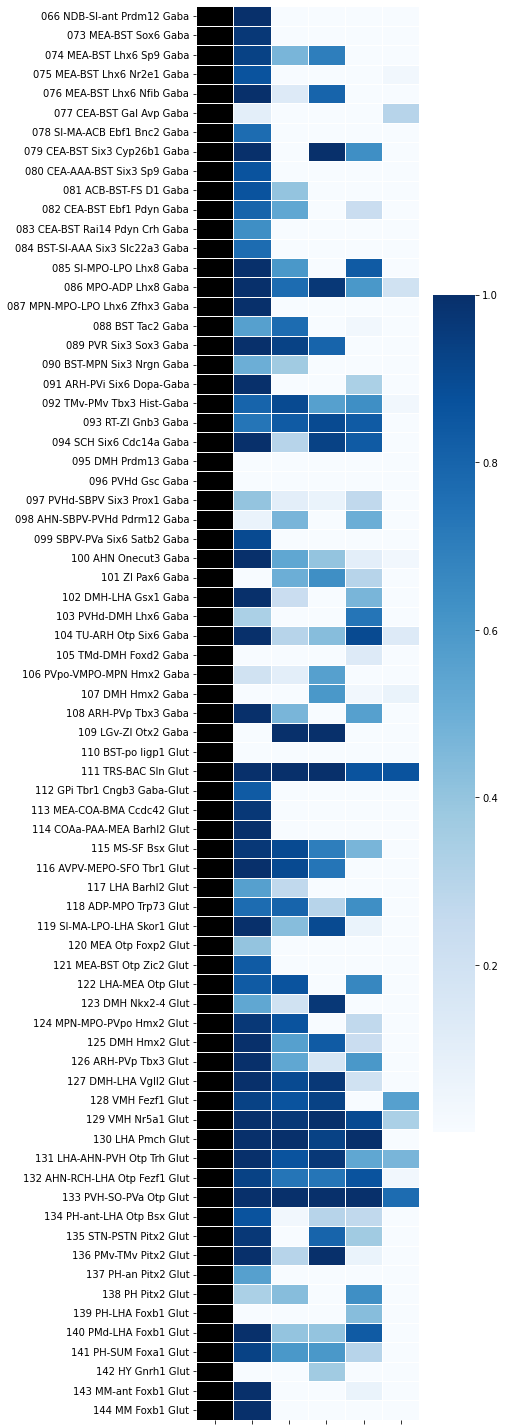

In [93]:
plt.figure(figsize=(5, 26))
ax = sns.heatmap(plt_df_saturn,vmin = .001,cmap = 'Blues',linewidth = .5)
ax.set_facecolor('black')
ax.set(xticklabels= [])
plt.savefig('Figures/Figures_06262026/Mapped_CT_mousefrac_saturn_Heatmap_boot_06262026.svg')
plt.savefig('Figures/Figures_06262026/mapped_CT_mousefrac_saturn_Heatmap_boot_06262026.png', bbox_inches = 'tight',dpi = 300)
plt.savefig('Figures/Figures_06262026/Mapped_CT_mousefrac_saturn_Heatmap_boot_06262026.pdf')

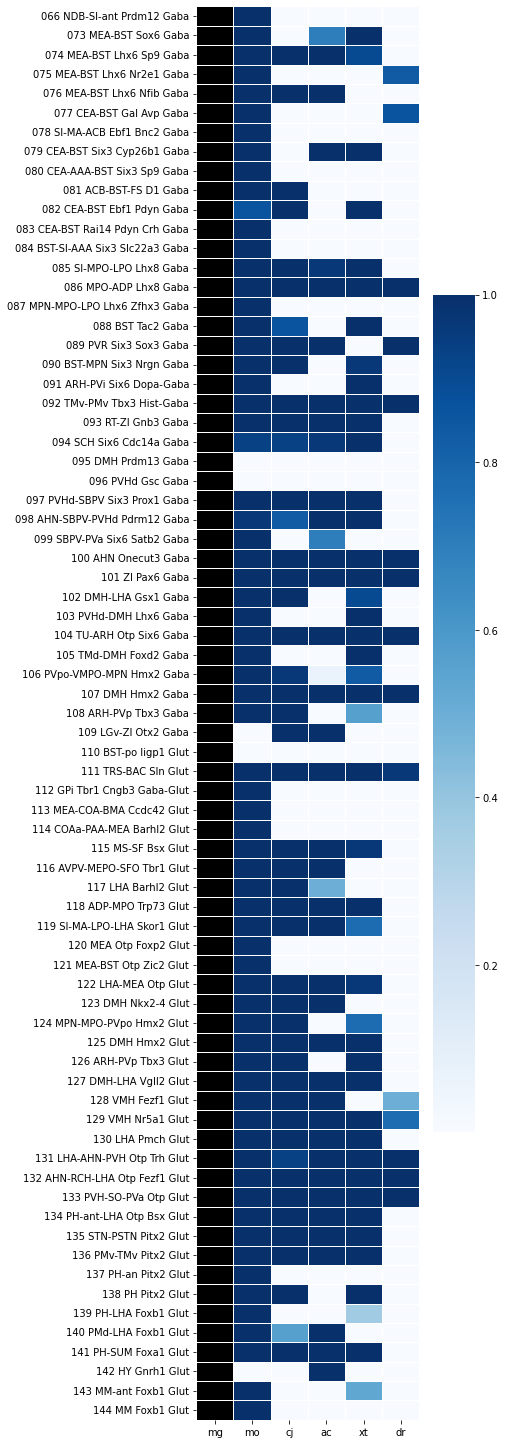

In [94]:
plt.figure(figsize=(5, 26),facecolor='white')
ax = sns.heatmap(plt_df_samap, vmin = 0.001, cmap = 'Blues',linewidth = .5)
ax.set_facecolor('black')
#ax.set(xticklabels= [])
#plt.figure(facecolor='white')
plt.savefig('Figures/Figures_06262026/Mapped_CT_mousefrac_samap_Heatmap_boot_06262026.svg')
plt.savefig('Figures/Figures_06262026/mapped_CT_mousefrac_samap_Heatmap_boot_06262026.png', bbox_inches = 'tight',dpi = 300)
plt.savefig('Figures/Figures_06262026/Mapped_CT_mousefrac_samap_Heatmap_boot_06262026.pdf')

In [33]:
plt_df_samap = plt_df_samap.loc[['095 DMH Prdm13 Gaba','096 PVHd Gsc Gaba','084 BST-SI-AAA Six3 Slc22a3 Gaba', '087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba',
       '137 PH-an Pitx2 Glut', '144 MM Foxb1 Glut',
       '076 MEA-BST Lhx6 Nfib Gaba', '116 AVPV-MEPO-SFO Tbr1 Glut',
       '117 LHA Barhl2 Glut', '123 DMH Nkx2-4 Glut', 'cj_xt_2', 'cj_xt_3',
       'cj_xt_4', 'cj_xt_6', 'cj_xt_dr_1', 'cj_ac_xt_dr_1', 'cj_ac_xt_dr_3',
       'cj_xt_dr_2', 'cj_xt_dr_3', 'cj_ac_1', 'cj_xt_5', 'cj_ac_xt_1',
       'xt_dr_1', 'cj_ac_xt_dr_2', 'cj_ac_xt_dr_4'],:]

In [32]:
plt_df_samap.index

Index(['084 BST-SI-AAA Six3 Slc22a3 Gaba', '087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba',
       '137 PH-an Pitx2 Glut', '144 MM Foxb1 Glut',
       '076 MEA-BST Lhx6 Nfib Gaba', '116 AVPV-MEPO-SFO Tbr1 Glut',
       '117 LHA Barhl2 Glut', '123 DMH Nkx2-4 Glut', 'cj_xt_2', 'cj_xt_3',
       'cj_xt_4', 'cj_xt_6', 'cj_xt_dr_1', 'cj_ac_xt_dr_1', 'cj_ac_xt_dr_3',
       'cj_xt_dr_2', 'cj_xt_dr_3', 'cj_ac_1', 'cj_xt_5', 'cj_ac_xt_1',
       'xt_dr_1', 'cj_ac_xt_dr_2', 'cj_ac_xt_dr_4', '095 DMH Prdm13 Gaba',
       '096 PVHd Gsc Gaba'],
      dtype='object')

In [83]:
plt_df_saturn.to_csv('SATURN_mousemapping_allorgs_06252026.csv')
plt_df_samap.to_csv('SAMAP_mousemapping_allorgs_06252026.csv')

In [3]:
plt_df_samap = pd.read_csv('Nonmammal_mapping_SAMap_04122026.csv', index_col = 'Unnamed: 0')
#plt_df_saturn = pd.read_csv('SATURN_mousemapping_allorgs_06162025.csv', index_col = 'Unnamed: 0')

In [4]:
plt_df_NT = pd.read_csv('Nonmammal_mapping_NT_04122026.csv', index_col = 'Unnamed: 0')

In [39]:
plt_df_NT.loc['095 DMH Prdm13 Gaba',:] = ['Gaba',np.nan,np.nan,np.nan,np.nan,np.nan]
plt_df_NT.loc['096 PVHd Gsc Gaba',:] = ['Gaba',np.nan,np.nan,np.nan,np.nan,np.nan]

In [40]:
plt_df_NT = plt_df_NT.loc[['095 DMH Prdm13 Gaba','096 PVHd Gsc Gaba','084 BST-SI-AAA Six3 Slc22a3 Gaba', '087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba',
       '137 PH-an Pitx2 Glut', '144 MM Foxb1 Glut',
       '076 MEA-BST Lhx6 Nfib Gaba', '116 AVPV-MEPO-SFO Tbr1 Glut',
       '117 LHA Barhl2 Glut', '123 DMH Nkx2-4 Glut', 'cj_xt_2', 'cj_xt_3',
       'cj_xt_4', 'cj_xt_6', 'cj_xt_dr_1', 'cj_ac_xt_dr_1', 'cj_ac_xt_dr_3',
       'cj_xt_dr_2', 'cj_xt_dr_3', 'cj_ac_1', 'cj_xt_5', 'cj_ac_xt_1',
       'xt_dr_1', 'cj_ac_xt_dr_2', 'cj_ac_xt_dr_4'],:]

In [41]:
nt_mapping = {'Gaba-Chol':1,
             'Chol':1,
             'Glut-Chol':1,
             'Glut-Gaba-Dopa':2,
             'Gaba-Dopa':2,
             'Dopa-Gaba':2,
             'Glut-Dopa':2,
             'Dopa':2,
             'Gly':3,
             'Hist':4,
             'Gaba':5,
             'Glut':6,
             'Gaba-Glut':7,
             'Glut-Gaba':7,
             'Gaba-Gly':3,
             'Glut-Gly': 3,
             'Glut-Gaba-Gly':3,
             'Gaba-Hist':4,
             'Hist-Gaba':4,
             'Nora':8,
             'Gaba-Sert':9,
             'Glut-Sert':9,
             'unclear':10,
             'Chol-Gly':11,
             'Sert':9,
             'Glut-Sert-Gly':12,
             'Gaba-Dopa-Sert':13,
             'Glut-Gaba-Hist':4,
             'Glut-Gaba-Sert-Hist':4}

In [42]:
nt_mapping

{'Gaba-Chol': 1,
 'Chol': 1,
 'Glut-Chol': 1,
 'Glut-Gaba-Dopa': 2,
 'Gaba-Dopa': 2,
 'Dopa-Gaba': 2,
 'Glut-Dopa': 2,
 'Dopa': 2,
 'Gly': 3,
 'Hist': 4,
 'Gaba': 5,
 'Glut': 6,
 'Gaba-Glut': 7,
 'Glut-Gaba': 7,
 'Gaba-Gly': 3,
 'Glut-Gly': 3,
 'Glut-Gaba-Gly': 3,
 'Gaba-Hist': 4,
 'Hist-Gaba': 4,
 'Nora': 8,
 'Gaba-Sert': 9,
 'Glut-Sert': 9,
 'unclear': 10,
 'Chol-Gly': 11,
 'Sert': 9,
 'Glut-Sert-Gly': 12,
 'Gaba-Dopa-Sert': 13,
 'Glut-Gaba-Hist': 4,
 'Glut-Gaba-Sert-Hist': 4}

In [18]:
plt_df_NT = plt_df_NT.reindex(index_sort)

NameError: name 'index_sort' is not defined

In [43]:
NT_df_numeric = plt_df_NT.replace(nt_mapping)

In [44]:
NT_df_numeric = NT_df_numeric.reindex(index_sort)

NameError: name 'index_sort' is not defined

In [45]:
custom_colors = ['#73E785','#FCF04B','#820E57','#FF7621','#FF3358','#2B93DF','#0A9964','#03EDFF','#4f2e91ff','black','pink','salmon','maroon','goldenrod']

In [46]:
custom_cmap = LinearSegmentedColormap.from_list('Custom', custom_colors, len(custom_colors))

In [47]:
NT_df_numeric

,mg,mo,cj,ac,xt,dr
095 DMH Prdm13 Gaba,5.0,NaN,NaN,NaN,NaN,NaN
096 PVHd Gsc Gaba,5.0,NaN,NaN,NaN,NaN,NaN
084 BST-SI-AAA Six3 Slc22a3 Gaba,5.0,5.0,NaN,NaN,NaN,NaN
087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba,5.0,5.0,NaN,NaN,NaN,NaN
137 PH-an Pitx2 Glut,6.0,6.0,NaN,NaN,NaN,NaN
144 MM Foxb1 Glut,6.0,6.0,NaN,NaN,NaN,NaN
076 MEA-BST Lhx6 Nfib Gaba,5.0,5.0,5.0,5.0,NaN,NaN
116 AVPV-MEPO-SFO Tbr1 Glut,6.0,6.0,6.0,6.0,NaN,NaN
117 LHA Barhl2 Glut,6.0,6.0,6.0,6.0,NaN,NaN
123 DMH Nkx2-4 Glut,6.0,6.0,6.0,6.0,NaN,NaN


In [48]:
NT_df_numeric = NT_df_numeric[NT_df_numeric.index != 'cj_dr_1']

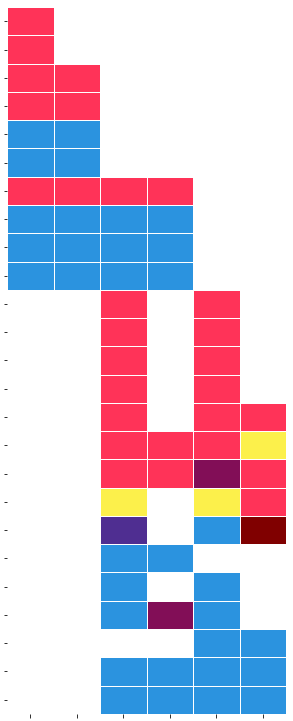

In [50]:
plt.figure(figsize=(5, 13))
ax = sns.heatmap(NT_df_numeric,cmap=custom_cmap, vmax = 14, vmin = 1, cbar = False, linewidth = .5)
ax.set(yticklabels= [])
ax.set(xticklabels= [])
plt.savefig('Figures/Figures_05222026/Nonmam_mapping_NT_05212026.svg')
plt.savefig('Figures/Figures_05222026/Nonmam_mapping_NT_05212026.png')

In [137]:
NT_df_numeric.to_csv('NT_mapping_allorgs_06162025.csv')

In [ ]:
#Numcells plotting

In [5]:
df = pd.read_csv('Allen_Institute_Numcells_RegionHY_04072026.csv')

In [8]:
HYPO = [i for i in df['cell_type'].unique() if parent_dict[parent_dict[i]] == 'hypo']

In [18]:
dfhypo = df[df['cell_type'].isin(HYPO)]

In [23]:
dfhypo = dfhypo.sort_values('cell_type')

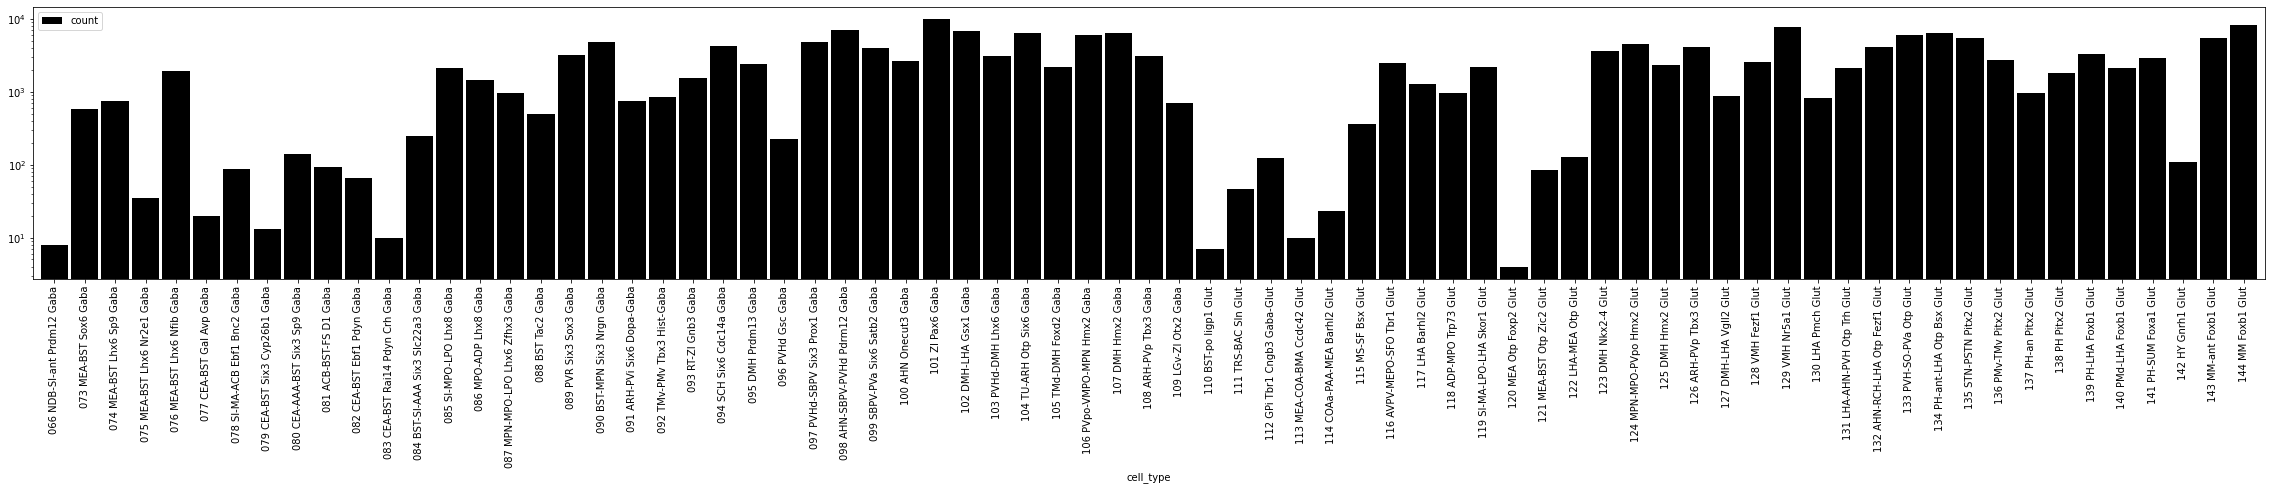

In [32]:
dfhypo.plot(kind='bar', x = 'cell_type',y='count', width = .9,color = 'black',figsize=(40,5))
plt.yscale('log')
plt.savefig('Figures/Figures_04102026/Numcells_CT_updated_04072026.png', bbox_inches = 'tight', dpi = 300)
plt.savefig('Figures/Figures_04102026/Numcells_CT_updated_04072026.svg')

In [34]:
df['fraction'] = df['count']/np.sum(df['count'])

In [36]:
df[df['cell_type'] == '095 DMH Prdm13 Gaba']

,Unnamed: 0,cell_type,count,fraction
29,29,095 DMH Prdm13 Gaba,2407,0.013146


In [37]:
df[df['cell_type'] == '096 PVHd Gsc Gaba']

,Unnamed: 0,cell_type,count,fraction
61,61,096 PVHd Gsc Gaba,224,0.001223


In [38]:
df[df['cell_type'] == '109 LGv-ZI Otx2 Gaba']

,Unnamed: 0,cell_type,count,fraction
51,51,109 LGv-ZI Otx2 Gaba,692,0.003779


In [39]:
df[df['cell_type'] == '110 BST-po Iigp1 Glut']

,Unnamed: 0,cell_type,count,fraction
117,117,110 BST-po Iigp1 Glut,7,0.000038


In [40]:
df[df['cell_type'] == '142 HY Gnrh1 Glut']

,Unnamed: 0,cell_type,count,fraction
69,69,142 HY Gnrh1 Glut,110,0.000601


In [41]:
df.to_csv('Allen_Institute_Numcells_RegionHY_04072026.csv')